# MEERKLASS-LIKE simulation

This is an example on the use of fastbox on simulatin meerklass DR2 - https://meerklass.org/HIdata.html and performing some simpple analysis, like foreground removal with weigthed PCA, power spectrum estimation and fit of Omega_HI*b_HI parameter

One need to run build_meerklass_geometry.py first. Just set the path of input file (meerklass data) and output path, and do 

python3 build_meerklass_geometry.py


In [1]:
from pathlib import Path

import numpy as np
import pyccl as ccl

import fastbox
from fastbox.foregrounds import ForegroundModel
from fastbox.power import Power
import pylab as plt
import fastbox.meerklass as mkt
from fastbox.beams import GaussianBeamModel


In [2]:
#LINE_FREQ_MHZ = 1420.405752
#C_LIGHT_M_S = 299792458.0
#DISH_DIAMETER_M = 13.5

# Supplied foreground prescription, all temperatures in mK.
FOREGROUND_PARAMETERS = {
    'amplitude': 700.0,
    'angular_power_index': -2.4,
    'spectral_index_mean': -2.80,
    'spectral_index_std': 0.10,
    'spectral_smoothing_deg': 0.9,
    'haslam_monopole_mK_at_408MHz': 30e3,
    'haslam_spectral_index': -2.8,
}

# Values are explicit assumptions, not a measurement from the released map.
FIDUCIAL_PARAMETERS = {
    'Omega_HI': 0.00086,
    'b_HI': 1.13,
    'b_gal': 1.90,
    'r_HI_gal': 0.90,
    'sigma_v_km_s': 120.0,
    'fog_model': 'lorentzian',
    'pca_modes': 3,
    'kmax_mpc_inverse': 0.20,
    'reconvolution_gamma': 1.4,
}



In [3]:
parameters = dict(FIDUCIAL_PARAMETERS)

## Load geometry parameters and hitmap weight

In [28]:
seed = 42
np.random.seed(seed)
geometry_path = Path(
    '/home/bruno/Downloads/13_fast/meerklass_example/'
    '/geometry_data/meerklass_deep_field_geometry.json'
)

geometry = mkt.load_geometry(geometry_path)

In [29]:
frequency, _mask_xy, weights_xyz, released_tsky_mK, raw_hits = mkt.load_released_window(geometry)

## DATA SIMULATION

In [30]:
cosmo = ccl.Cosmology(**geometry['cosmology'])
box = fastbox.CosmoBox(
    cosmo=cosmo,
    box_scale=tuple(geometry['box_scale_mpc']),
    nsamp=tuple(geometry['fastbox_shape_x_y_z']),
    redshift=float(geometry['central_redshift']),
    realise_now=False,
    frequency_array=frequency
)

### HI

In [7]:
box.realise_density(linear=True, inplace=True)
delta_m = box.delta_x

z_eff = float(geometry['central_redshift'])
a_eff = 1.0 / (1.0 + z_eff)

E = ccl.h_over_h0(box.cosmo, a_eff)
Tb = 188.0 * box.cosmo['h'] * parameters['Omega_HI'] * (1.0 + z_eff)**2 / E

delta_hi_s = box.linear_rsd_density(
    delta_x=delta_m,
    bias=parameters['b_HI'],
    sigma_v=parameters['sigma_v_km_s'],
    fog_model='lorentzian',
    redshift=z_eff,
)

# Temperature-fluctuation cube. Mean is Tb; fluctuations are Tb * delta_HI^s.
hi_cube = Tb * (1.0 + delta_hi_s)
hi_fluctuation_cube = Tb * delta_hi_s


 /home/bruno/anaconda3/envs/fast-test/lib/python3.8/site-packages/pyccl/pk2d.py:207: RuntimeWarning:divide by zero encountered in log


### Galaxies

In [8]:
delta_gal_s = box.linear_rsd_density(
    delta_x=delta_m,
    bias=parameters['b_gal'],
    sigma_v=parameters['sigma_v_km_s'],
    fog_model='lorentzian',
    redshift=z_eff,
)

'''
# We use directly delta_gal_s instead of Poisson sampling a catalog from it,
# in order to have less variance in our simple estimatives
gal_tracer = fastbox.tracers.GalaxyTracer(box=box, vol_density=1e-3, bias=parameters['b_gal'])
galaxy_coordinates = gal_tracer.generate_catalogue(delta_gal_s)
mesh_g = gal_tracer._assign_cic(galaxy_coordinates,overdensity=True)
'''


"\n# We use directly delta_gal_s instead of Poisson sampling a catalog from it,\n# in order to have less variance in our simple estimatives\ngal_tracer = fastbox.tracers.GalaxyTracer(box=box, vol_density=1e-3, bias=parameters['b_gal'])\ngalaxy_coordinates = gal_tracer.generate_catalogue(delta_gal_s)\nmesh_g = gal_tracer._assign_cic(galaxy_coordinates,overdensity=True)\n"

### Foregrounds

In [9]:
frequency_reference = float(np.mean(frequency))
monopole = (
    FOREGROUND_PARAMETERS['haslam_monopole_mK_at_408MHz']
    * (frequency_reference / 408.0) ** FOREGROUND_PARAMETERS['haslam_spectral_index']
)
foreground = ForegroundModel(box)
amplitude_map = foreground.realise_foreground_amp(
    amp=FOREGROUND_PARAMETERS['amplitude'],
    beta=FOREGROUND_PARAMETERS['angular_power_index'],
    monopole=monopole,
    redshift=z_eff,
)
spectral_index = foreground.realise_spectral_index(
    mean_spec_idx=FOREGROUND_PARAMETERS['spectral_index_mean'],
    std_spec_idx=FOREGROUND_PARAMETERS['spectral_index_std'],
    smoothing_scale=FOREGROUND_PARAMETERS['spectral_smoothing_deg'],
    redshift=z_eff)

fg_cube = foreground.construct_cube(amplitude_map, spectral_index,
                                 freq_ref=frequency_reference, redshift=z_eff)

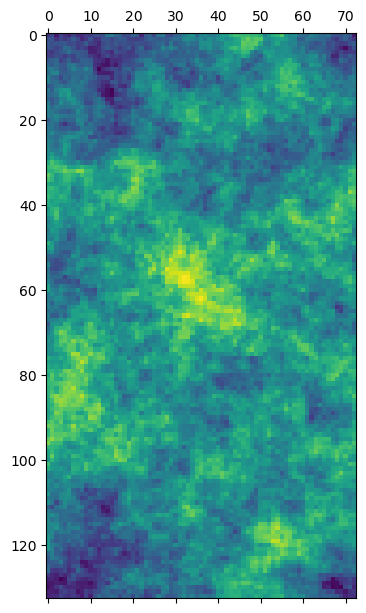

In [10]:
plt.matshow(fg_cube[:,:,0])

### Gaussian reconvolved beam

In [11]:
# get the beam width
sigma_beam_deg = mkt.effective_reconvolved_beam_sigma_deg(
    frequency, parameters['reconvolution_gamma']
)

# get Gaussian beam
beam_mod = GaussianBeamModel(box, sigma_beam_deg)
beam_cube = beam_mod.beam_cube()
m_raw = np.fft.fftn(
    np.fft.ifftshift(beam_cube, axes=(0, 1)),
    axes=(0, 1),
)

# Normalize independently in each frequency channel:
# B_k(k_perp=0, nu) = 1.
beam_sum = m_raw[0, 0, :].real
B_k = m_raw / beam_sum[None, None, :]

# Apply beam
fourier_cube = np.fft.fftn(hi_fluctuation_cube+fg_cube, axes=(0,1))
data_conv = np.fft.ifftn(B_k * fourier_cube, axes=(0,1)).real

In [12]:
# CUT DATA IN RIGHT FOOTPRINT

data_conv_cut = data_conv.copy()
data_conv_cut[weights_xyz==0]=0


### Thermal noise based on hitmap

In [13]:
noise_cube = mkt.hitmap_thermal_noise(box, raw_hits,_mask_xy,frequency,t_sample_s=2.0)

In [14]:
# Final HI data
data = data_conv_cut+noise_cube

In [15]:
noise_cube.max()

7.027940101687202

## foreground cleaning

In [16]:
cleaned = mkt.pca_masked_weighted(parameters['pca_modes'], data, _mask_xy, raw_hits,  return_modes=False)

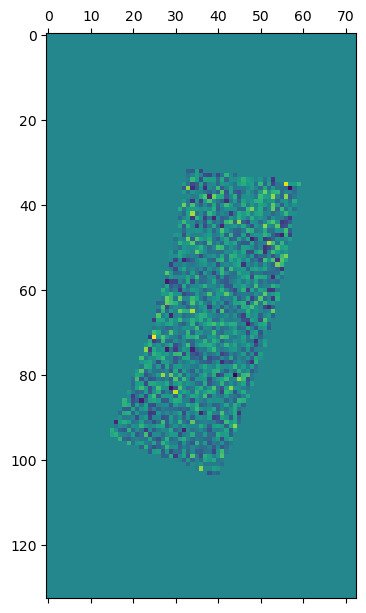

In [17]:
plt.matshow(cleaned[:,:,0])

## POWER SPECTRUM

In [18]:
hi_comparison = hi_cube.copy()

fourier_hi = np.fft.fftn(hi_fluctuation_cube, axes=(0,1))
hi_comparison = np.fft.ifftn(B_k * fourier_hi, axes=(0,1)).real
hi_comparison[weights_xyz==0] = 0
hi_comparison +=noise_cube

In [19]:
estimator = Power(box)
k_data, p_data, p_data_error = estimator.weighted_power(
        hi_comparison,w1=weights_xyz)
k_data, p_data_cl, p_data_error_cl = estimator.weighted_power(
        cleaned, w1=weights_xyz )
k_data, p_data_cl, p_data_error_cl = estimator.weighted_power(
        cleaned, w1=weights_xyz )

Calculating auto-correlation power spectrum...
DONE
Calculating auto-correlation power spectrum...
DONE
Calculating auto-correlation power spectrum...
DONE


In [20]:
km,pkm = estimator.matter_power_spectrum(k_data,rsd=False,sigma_nl=0)

k, pk_hi_obs, std_hi_obs = estimator.model_obs_power_IM(k_data, 
                                                pkm, 
                                                    bias=parameters['b_HI'],
                                                    Tb = Tb,
                                                    sigdeg=sigma_beam_deg, 
                                                    rsd = True,
                                                    sigma_nl=parameters['sigma_v_km_s'],
                                                    fog_model='lorentzian')

DONE


In [21]:
k, p_noise, _ = estimator.weighted_power(
    noise_cube,
    w1=weights_xyz,
)

Calculating auto-correlation power spectrum...
DONE


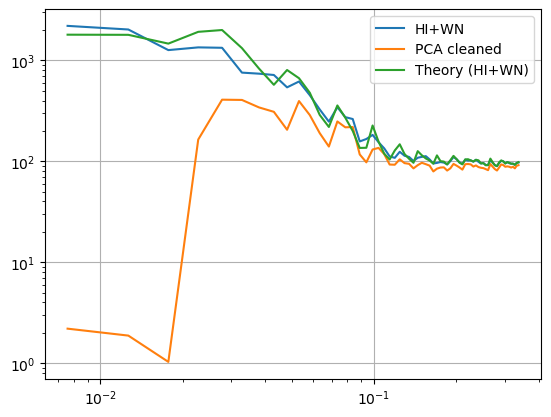

In [22]:
plt.loglog(k_data,p_data,label='HI+WN')
plt.loglog(k_data,p_data_cl,label='PCA cleaned')
plt.loglog(k, pk_hi_obs+p_noise,label='Theory (HI+WN)')
plt.legend()
plt.grid()
plt.show()

## CROSS POWER SPECTRUM

In [23]:
galaxy_for_cross = delta_gal_s.copy()
galaxy_for_cross[weights_xyz == 0.0] = 0.0

weights_gal = np.ones_like(weights_xyz)
weights_gal[weights_xyz==0]=0

k_cc, p_cc, p_cc_err = estimator.weighted_power(
    cleaned,
    delta_gal_s,
    w1=weights_xyz,
    w2=weights_gal,
)


k, pk_X_obs, std_X_obs = estimator.model_obs_power_CC(k, 
                                                  pkm, 
                                                  bias_HI=parameters['b_HI'],
                                                  bias_gal = parameters['b_gal'],
                                                  Tb = Tb,
                                                  sigdeg=sigma_beam_deg,
                                                  MAS = None,
                                                  rsd = True,
                                                  sigma_nl=parameters['sigma_v_km_s'],
                                                  fog_model='lorentzian')


Calculating cross-correlation power spectrum
DONE
DONE


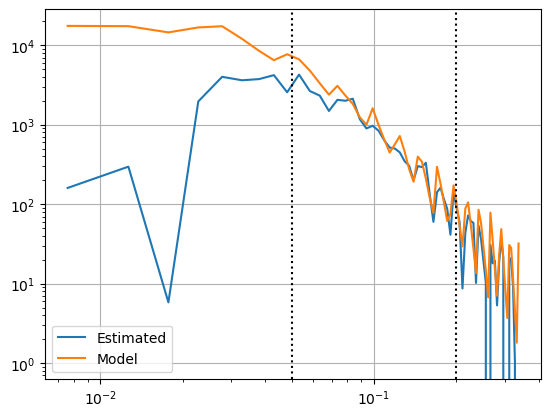

In [24]:
plt.loglog(k_cc, p_cc, label='Estimated')
plt.loglog(k, pk_X_obs, label='Model')
plt.legend()
plt.axvline(0.05,color='k',linestyle=':')
plt.axvline(0.2,color='k',linestyle=':')
plt.grid()
plt.show()

## FIT PARAMETERS

In [25]:
# ---------------------------------------------------------------
# One-parameter fit: theta = Omega_HI * b_HI, with r_HI_gal = 1.
# ---------------------------------------------------------------

theta_fid = parameters['Omega_HI'] * parameters['b_HI']

# For the currently CLEANED field, this must be a PCA- and window-processed
# forward template, not the raw analytic pk_X_obs. See below.
k_template = k
pk_template = pk_X_obs

# Put model onto exactly the estimator bin centres.
template_at_data = np.interp(k_cc, k_template, pk_template)

kmin_fit = 0.03      # conservative initial lower limit after PCA cleaning
kmax_fit = 0.20      # native-grid analysis upper limit

fit_mask = (
    (k_cc >= kmin_fit)
    & (k_cc <= kmax_fit)
    & np.isfinite(p_cc)
    & np.isfinite(p_cc_err)
    & np.isfinite(template_at_data)
    & (p_cc_err > 0.0)
)

# Diagonal inverse-variance weighted least-squares amplitude.
inv_var = 1.0 / p_cc_err[fit_mask]**2
numerator = np.sum(inv_var * p_cc[fit_mask] * template_at_data[fit_mask])
denominator = np.sum(inv_var * template_at_data[fit_mask]**2)

amplitude = numerator / denominator
amplitude_error = 1.0 / np.sqrt(denominator)

theta_fit = amplitude * theta_fid
theta_error = amplitude_error * theta_fid

chi2 = np.sum(
    ((p_cc[fit_mask] - amplitude * template_at_data[fit_mask])
     / p_cc_err[fit_mask])**2
)
dof = fit_mask.sum() - 1

print(f'Fiducial Omega_HI * b_HI = {theta_fid:.6e}')
print(f'Amplitude ratio A            = {amplitude:.4f} ± {amplitude_error:.4f}')
print(f'Fit Omega_HI * b_HI          = {theta_fit:.6e} ± {theta_error:.6e}')
print(f'chi2 / dof                   = {chi2:.2f} / {dof}')


Fiducial Omega_HI * b_HI = 9.718000e-04
Amplitude ratio A            = 0.6588 ± 0.0139
Fit Omega_HI * b_HI          = 6.402469e-04 ± 1.354911e-05
chi2 / dof                   = 341.69 / 32
